---

<div align='center'>

# 🎵 PROJETO FINAL DE CIÊNCIA DE DADOS — TCC
## Previsão de Popularidade de Músicas no Spotify
### *Aplicando Machine Learning para entender o que faz uma música fazer sucesso*

---

| Campo | Informação |
|---|---|
| **Curso** | MBA em Ciência de Dados — FM2S |
| **Aluno** | José Alexandre dos Santos Junior |
| **Empresa** | SoundMetrics Analytics Ltda. |
| **Dataset** | Spotify Tracks Dataset (114.000 faixas, 114 gêneros) |
| **Problema** | Regressão + Análise Exploratória de Popularidade Musical |
| **Ano** | 2026 |

</div>

---

## 📋 CONTEXTO DO PROJETO

### 🏢 1. A Empresa — SoundMetrics Analytics Ltda.

A **SoundMetrics Analytics Ltda.** é uma empresa brasileira de consultoria em dados fundada em 2019, especializada em **análise de dados para a indústria musical e de entretenimento**. Atua principalmente com:

- 📊 **Análise de tendências musicais** para gravadoras e artistas independentes
- 🎯 **Recomendação de estratégias de lançamento** baseada em dados de streaming
- 📈 **Previsão de desempenho de faixas** em plataformas digitais (Spotify, Deezer, Apple Music)
- 🤖 **Desenvolvimento de modelos preditivos** para identificar potencial de hits
- 📱 **Dashboards executivos** para acompanhamento de campanhas de marketing musical

A empresa atende gravadoras independentes, agências de artistas e plataformas de streaming que buscam entender o comportamento de consumo musical com base em dados.

---

### 👩‍💻 2. Minha Função

Atuo como **Cientista de Dados Sênior** na SoundMetrics Analytics, sendo responsável por:

- Coleta, limpeza e análise de grandes volumes de dados de streaming
- Construção de modelos preditivos de popularidade e tendências
- Geração de relatórios e visualizações para clientes da indústria musical
- Tradução de insights analíticos em recomendações estratégicas de negócio

Este projeto surgiu de uma **demanda real de um cliente** — uma gravadora independente que deseja entender quais atributos musicais mais influenciam a popularidade de uma faixa no Spotify, para orientar suas decisões de produção e investimento.

---

### 👥 3. Equipe do Projeto

| Membro | Cargo | Papel no Projeto |
|---|---|---|
| José Alexandre dos Santos Junior | Cientista de Dados Sênior | Líder técnico — modelagem e análise |
| Rafael Drummond | Engenheiro de Dados | Extração e pipeline de dados da API Spotify |
| Camila Vaz | Analista de Negócios | Tradução dos insights em estratégia musical |
| Pedro Henrique Lima | UX/Data Storytelling | Visualizações e apresentação para clientes |

---

### ❗ 4. A Problemática

**Desafio:** A gravadora investe em média R\$ 80.000 por lançamento (produção, marketing, distribuição), mas apenas **~15% das faixas** atingem popularidade acima de 50 pontos no Spotify — métrica que indica alcance real e retorno financeiro.

**Pergunta central:**
> *"Quais características sonoras e de gênero musical mais influenciam a popularidade de uma faixa no Spotify? É possível prever o score de popularidade antes do lançamento?"*

**Perguntas derivadas:**
1. Quais gêneros musicais têm, em média, maior popularidade?
2. Existe correlação entre dançabilidade (`danceability`), energia (`energy`) e popularidade?
3. Músicas explícitas tendem a ser mais populares?
4. Qual a duração ideal de uma faixa para maximizar popularidade?
5. É possível construir um modelo preditivo confiável de popularidade?

---

---
# 📦 PASSO 1 — IMPORTAR DADOS
---

In [1]:
# ──────────────────────────────────────────────────────────────────────────────
# 1.1  Instalar / importar todas as bibliotecas necessárias
# ──────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.linear_model     import LinearRegression, Ridge, Lasso
from sklearn.ensemble         import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree             import DecisionTreeRegressor
from sklearn.metrics          import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline         import Pipeline
from scipy                    import stats

# Configurações visuais globais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family']    = 'DejaVu Sans'
VERDE   = '#1DB954'   # Verde Spotify
ESCURO  = '#191414'   # Preto Spotify
AZUL    = '#2980B9'
LARANJA = '#E67E22'
VERMELHO= '#E74C3C'

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


In [2]:
# ──────────────────────────────────────────────────────────────────────────────
# 1.2  Carregar o dataset
#      ⚠️  Faça o upload do arquivo 'spotify-tracks-dataset.csv' no Colab
#          (clique no ícone de pasta à esquerda → Upload) OU use o código
#          abaixo para fazer o upload direto.
# ──────────────────────────────────────────────────────────────────────────────

# Opção A: upload manual via painel do Colab
# from google.colab import files
# uploaded = files.upload()   # selecione o arquivo .csv

# Opção B: ler diretamente se já fez upload
df = pd.read_csv('spotify-tracks-dataset.csv', index_col=0)

# Remover coluna de índice duplicada, se presente
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print(f'✅  Dataset carregado com sucesso!')
print(f'    Linhas   : {df.shape[0]:,}')
print(f'    Colunas  : {df.shape[1]}')
print(f'    Gêneros  : {df["track_genre"].nunique()}')
print(f'    Artistas : {df["artists"].nunique():,}')

✅  Dataset carregado com sucesso!
    Linhas   : 114,000
    Colunas  : 20
    Gêneros  : 114
    Artistas : 31,437


In [3]:
# ──────────────────────────────────────────────────────────────────────────────
# 1.3  Primeiras linhas e dicionário de dados
# ──────────────────────────────────────────────────────────────────────────────
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
# Dicionário de dados — o que significa cada coluna?
dicionario = {
    'track_id'        : 'ID único da faixa no Spotify',
    'artists'         : 'Nome(s) do(s) artista(s)',
    'album_name'      : 'Nome do álbum',
    'track_name'      : 'Nome da faixa',
    'popularity'      : 'Score de popularidade (0–100) — variável-alvo 🎯',
    'duration_ms'     : 'Duração da faixa em milissegundos',
    'explicit'        : 'Conteúdo explícito? (True/False)',
    'danceability'    : 'Quão dançável é a música (0.0–1.0)',
    'energy'          : 'Intensidade e atividade percebida (0.0–1.0)',
    'key'             : 'Tom musical (0=Dó, 1=Dó#, ... 11=Si)',
    'loudness'        : 'Volume médio em decibéis (dB)',
    'mode'            : 'Modalidade: 1=Maior (alegre), 0=Menor (melancólico)',
    'speechiness'     : 'Presença de palavras faladas (0.0–1.0)',
    'acousticness'    : 'Probabilidade de ser acústica (0.0–1.0)',
    'instrumentalness': 'Probabilidade de não ter vocais (0.0–1.0)',
    'liveness'        : 'Probabilidade de ser ao vivo (0.0–1.0)',
    'valence'         : 'Positividade musical (0.0=triste → 1.0=feliz)',
    'tempo'           : 'Andamento em BPM (batidas por minuto)',
    'time_signature'  : 'Compasso da música (ex: 4 = 4/4)',
    'track_genre'     : 'Gênero musical da faixa'
}

pd.DataFrame.from_dict(dicionario, orient='index', columns=['Descrição'])

,Descrição
track_id,ID único da faixa no Spotify
artists,Nome(s) do(s) artista(s)
album_name,Nome do álbum
track_name,Nome da faixa
popularity,Score de popularidade (0–100) — variável-alvo 🎯
duration_ms,Duração da faixa em milissegundos
explicit,Conteúdo explícito? (True/False)
danceability,Quão dançável é a música (0.0–1.0)
energy,Intensidade e atividade percebida (0.0–1.0)
key,"Tom musical (0=Dó, 1=Dó#, ... 11=Si)"


---
# 🔍 PASSO 2 — AVALIAR A QUALIDADE DOS DADOS
---

In [5]:
# ──────────────────────────────────────────────────────────────────────────────
# 2.1  Informações gerais — tipos, nulos, memória
# ──────────────────────────────────────────────────────────────────────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 

In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# 2.2  Estatísticas descritivas das variáveis numéricas
# ──────────────────────────────────────────────────────────────────────────────
df.describe().T.style.background_gradient(cmap='Greens', subset=['mean','50%'])

,count,mean,std,min,25%,50%,75%,max
popularity,114000.000000,33.238535,22.305078,0.000000,17.000000,35.000000,50.000000,100.000000
duration_ms,114000.000000,228029.153114,107297.712645,0.000000,174066.000000,212906.000000,261506.000000,5237295.000000
danceability,114000.000000,0.566800,0.173542,0.000000,0.456000,0.580000,0.695000,0.985000
energy,114000.000000,0.641383,0.251529,0.000000,0.472000,0.685000,0.854000,1.000000
key,114000.000000,5.309140,3.559987,0.000000,2.000000,5.000000,8.000000,11.000000
loudness,114000.000000,-8.258960,5.029337,-49.531000,-10.013000,-7.004000,-5.003000,4.532000
mode,114000.000000,0.637553,0.480709,0.000000,0.000000,1.000000,1.000000,1.000000
speechiness,114000.000000,0.084652,0.105732,0.000000,0.035900,0.048900,0.084500,0.965000
acousticness,114000.000000,0.314910,0.332523,0.000000,0.016900,0.169000,0.598000,0.996000
instrumentalness,114000.000000,0.156050,0.309555,0.000000,0.000000,0.000042,0.049000,1.000000


⚠️  Colunas com valores nulos:


,Valores Nulos,% do Total
artists,1,0.0009
album_name,1,0.0009
track_name,1,0.0009


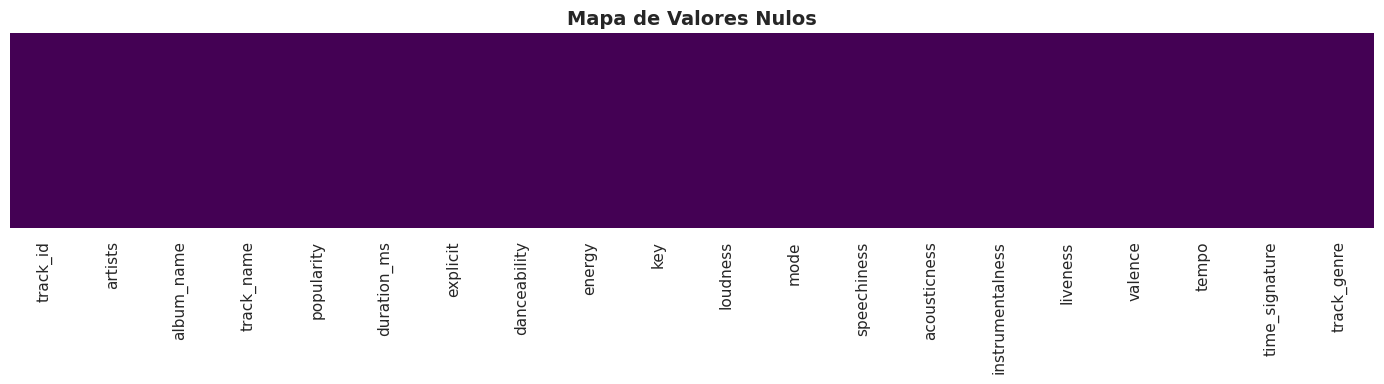

In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# 2.3  Verificação de valores nulos
# ──────────────────────────────────────────────────────────────────────────────
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(4)

df_nulos = pd.DataFrame({'Valores Nulos': nulos, '% do Total': pct})
df_nulos = df_nulos[df_nulos['Valores Nulos'] > 0]

if df_nulos.empty:
    print('✅  Nenhum valor nulo encontrado no dataset!')
else:
    print('⚠️  Colunas com valores nulos:')
    display(df_nulos)

# Visualizar heatmap de nulos
plt.figure(figsize=(14, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de Valores Nulos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# 2.4  Verificação de duplicatas
# ──────────────────────────────────────────────────────────────────────────────
dup_full    = df.duplicated().sum()
dup_trackid = df['track_id'].duplicated().sum()

print(f'Linhas totalmente duplicadas       : {dup_full:,}')
print(f'track_ids duplicados (mesma faixa  '
      f'em múltiplos gêneros): {dup_trackid:,}')
print(f'\n💡 Nota: track_ids duplicados são esperados — a mesma faixa pode')
print(f'   aparecer em mais de um gênero na base de dados do Spotify.')

Linhas totalmente duplicadas       : 450
track_ids duplicados (mesma faixa  em múltiplos gêneros): 24,259

💡 Nota: track_ids duplicados são esperados — a mesma faixa pode
   aparecer em mais de um gênero na base de dados do Spotify.


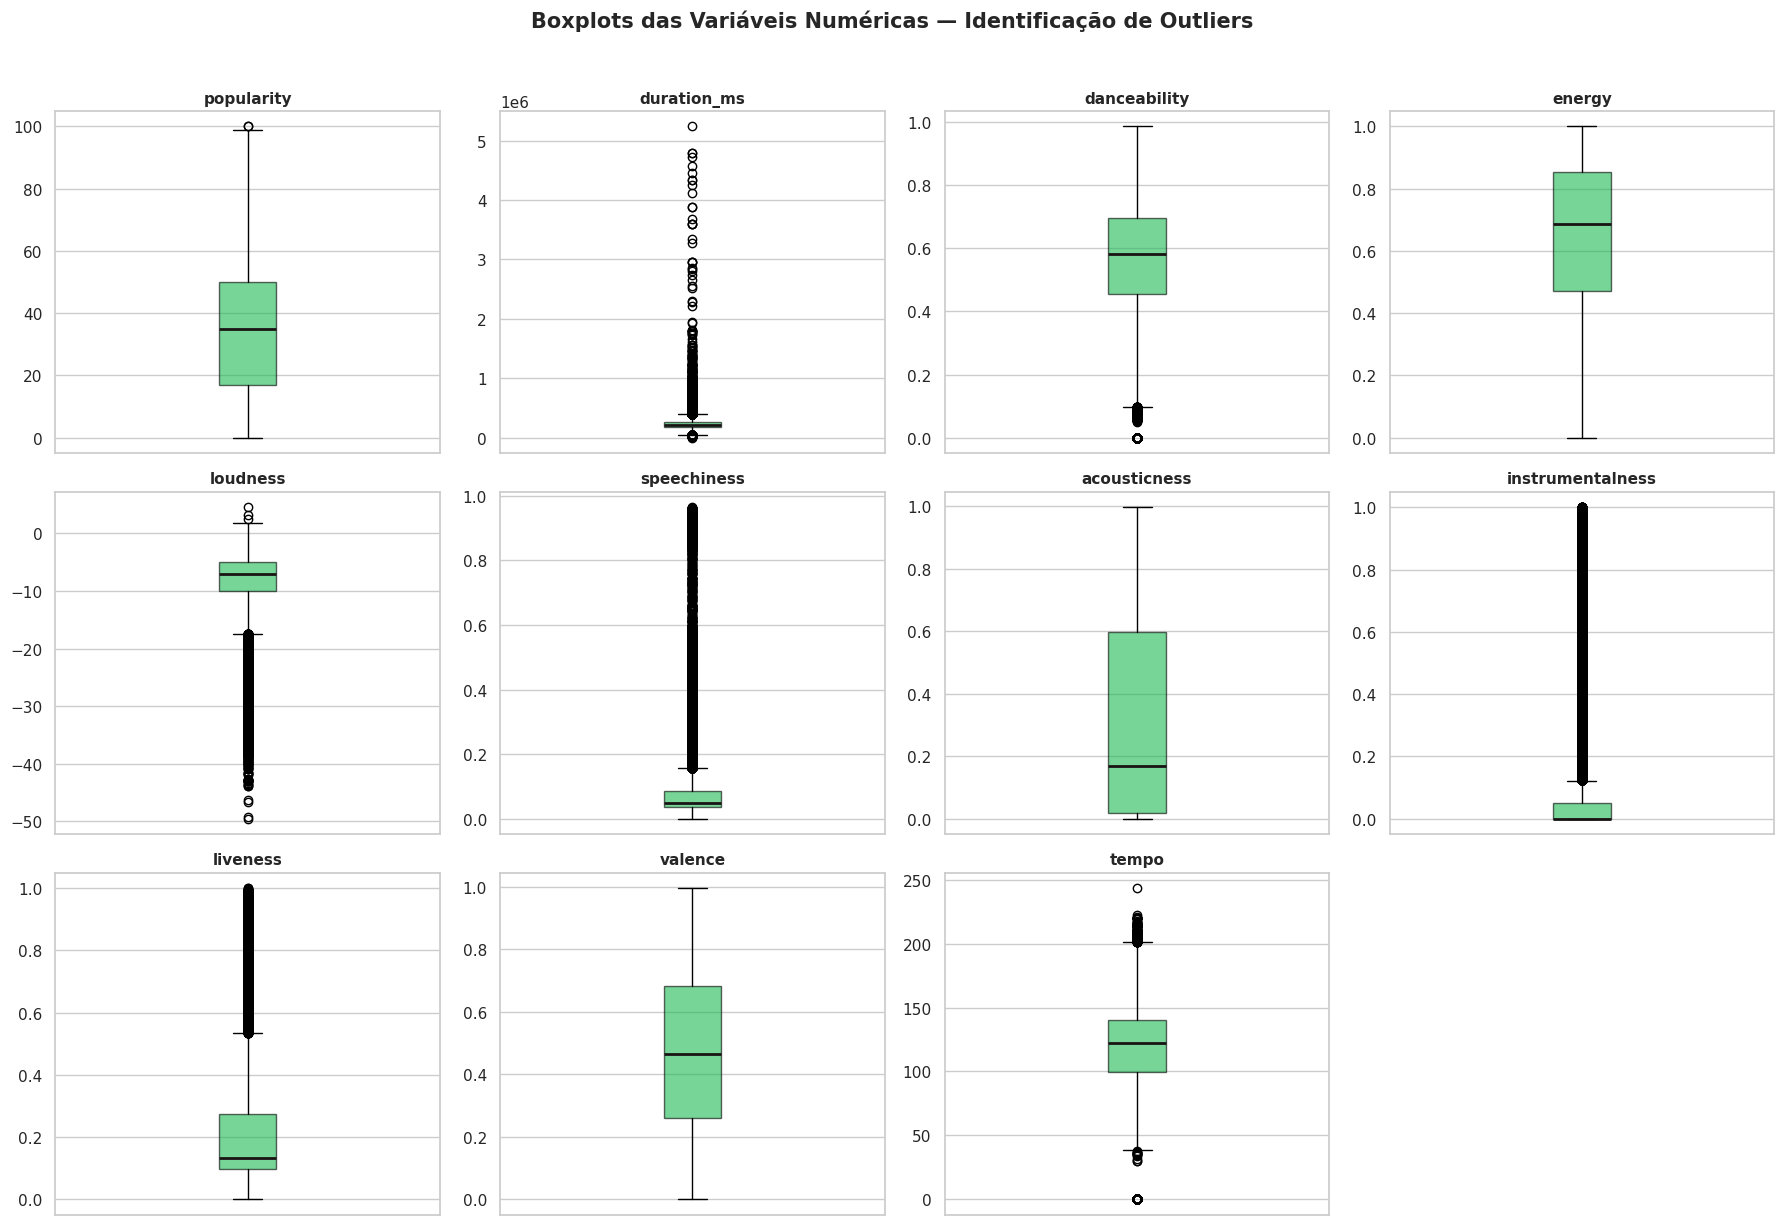

In [9]:
# ──────────────────────────────────────────────────────────────────────────────
# 2.5  Verificação de outliers — Boxplots
# ──────────────────────────────────────────────────────────────────────────────
cols_num = ['popularity','duration_ms','danceability','energy',
            'loudness','speechiness','acousticness',
            'instrumentalness','liveness','valence','tempo']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=VERDE, alpha=0.6),
                    medianprops=dict(color=ESCURO, linewidth=2))
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_xticks([])

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplots das Variáveis Numéricas — Identificação de Outliers',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# ──────────────────────────────────────────────────────────────────────────────
# 2.6  Tratamento de nulos e anomalias detectadas
# ──────────────────────────────────────────────────────────────────────────────

# 2.6.1  Preencher nulos de texto com 'Desconhecido'
cols_texto = ['artists', 'album_name', 'track_name']
for c in cols_texto:
    df[c].fillna('Desconhecido', inplace=True)

# 2.6.2  Converter duration de ms → minutos (mais legível)
df['duration_min'] = (df['duration_ms'] / 60000).round(2)

# 2.6.3  Remover faixas com duração inválida (< 10s ou > 15min)
antes = len(df)
df = df[(df['duration_min'] >= 0.17) & (df['duration_min'] <= 15)]
print(f'Faixas removidas por duração inválida : {antes - len(df):,}')

# 2.6.4  Converter 'explicit' para int (0/1) para uso no modelo
df['explicit_int'] = df['explicit'].astype(int)

print(f'✅  Dataset após tratamento: {df.shape[0]:,} linhas × {df.shape[1]} colunas')

Faixas removidas por duração inválida : 153
✅  Dataset após tratamento: 113,847 linhas × 22 colunas


---
# 📊 PASSO 3 — AVALIAR O COMPORTAMENTO DAS VARIÁVEIS
---

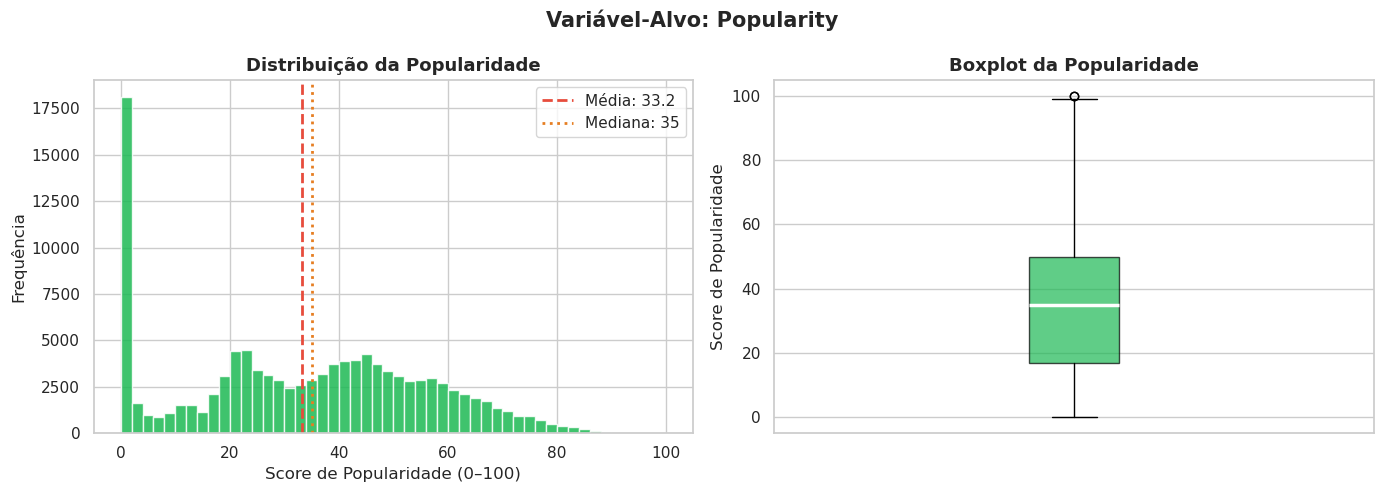

Assimetria (skewness): 0.046
Curtose (kurtosis)   : -0.928


In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# 3.1  Distribuição da variável-alvo: POPULARIDADE
# ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['popularity'], bins=50, color=VERDE, edgecolor='white', alpha=0.85)
axes[0].axvline(df['popularity'].mean(),   color=VERMELHO,  lw=2, ls='--',
                label=f'Média: {df["popularity"].mean():.1f}')
axes[0].axvline(df['popularity'].median(), color=LARANJA, lw=2, ls=':',
                label=f'Mediana: {df["popularity"].median():.0f}')
axes[0].set_title('Distribuição da Popularidade', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Score de Popularidade (0–100)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['popularity'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=VERDE, alpha=0.7),
                medianprops=dict(color='white', linewidth=2.5))
axes[1].set_title('Boxplot da Popularidade', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Score de Popularidade')
axes[1].set_xticks([])

plt.suptitle('Variável-Alvo: Popularity', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Assimetria (skewness): {df['popularity'].skew():.3f}")
print(f"Curtose (kurtosis)   : {df['popularity'].kurtosis():.3f}")

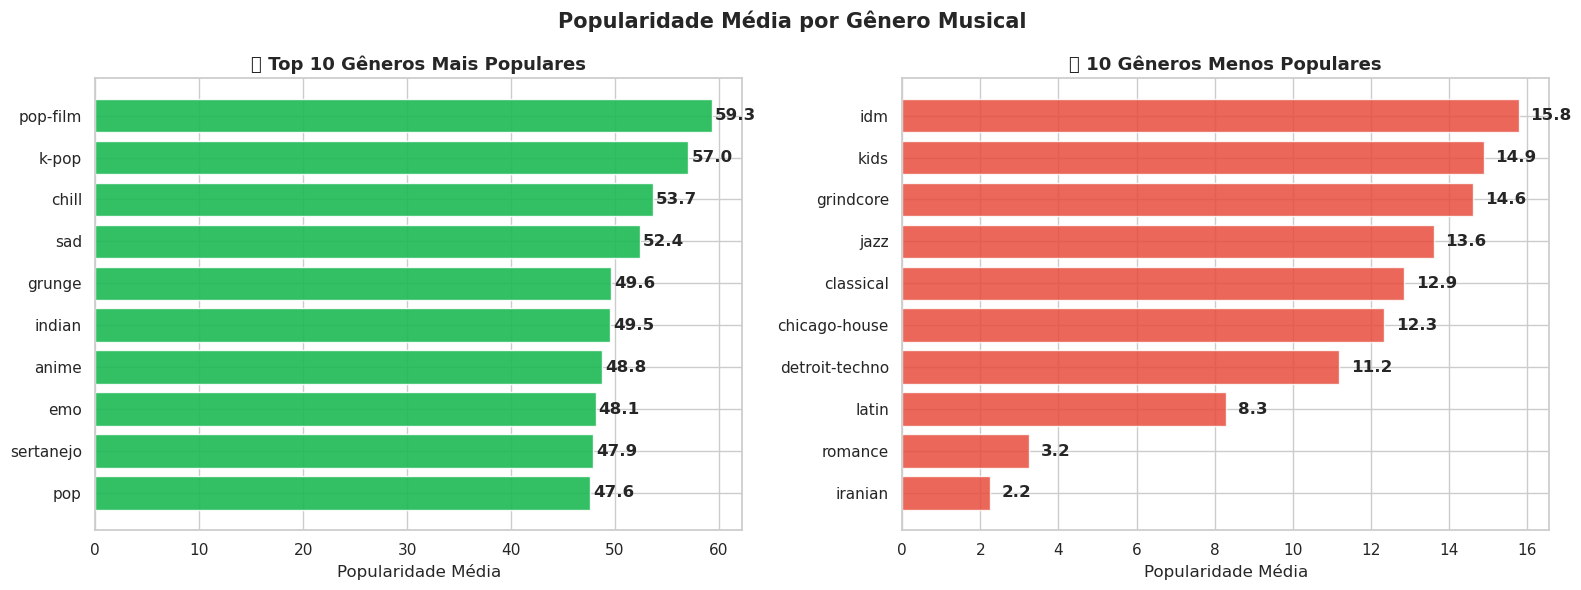

In [12]:
# ──────────────────────────────────────────────────────────────────────────────
# 3.2  Top 10 gêneros mais e menos populares
# ──────────────────────────────────────────────────────────────────────────────
pop_genre = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 mais populares
top10 = pop_genre.head(10)
bars = axes[0].barh(top10.index[::-1], top10.values[::-1],
                    color=VERDE, edgecolor='white', alpha=0.9)
axes[0].set_title('🏆 Top 10 Gêneros Mais Populares', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Popularidade Média')
for bar, val in zip(bars, top10.values[::-1]):
    axes[0].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}', va='center', fontweight='bold')

# Bottom 10 menos populares
bot10 = pop_genre.tail(10)
bars2 = axes[1].barh(bot10.index[::-1], bot10.values[::-1],
                     color=VERMELHO, edgecolor='white', alpha=0.85)
axes[1].set_title('📉 10 Gêneros Menos Populares', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Popularidade Média')
for bar, val in zip(bars2, bot10.values[::-1]):
    axes[1].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}', va='center', fontweight='bold')

plt.suptitle('Popularidade Média por Gênero Musical', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

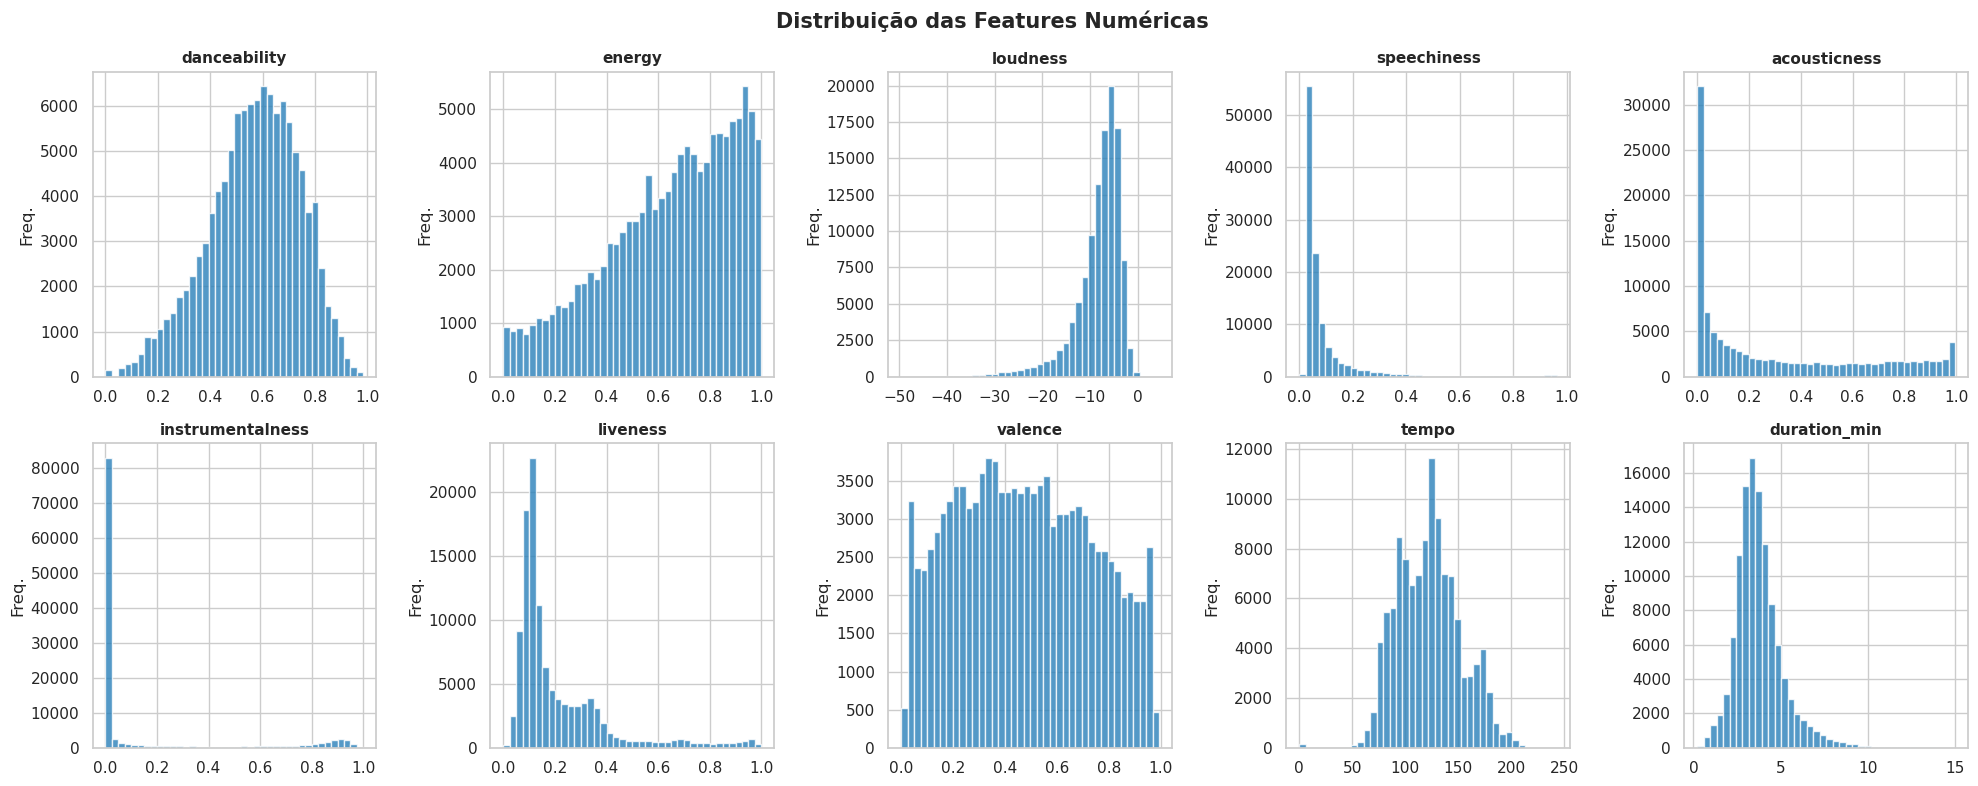

In [13]:
# ──────────────────────────────────────────────────────────────────────────────
# 3.3  Histogramas de todas as features numéricas
# ──────────────────────────────────────────────────────────────────────────────
features = ['danceability','energy','loudness','speechiness',
            'acousticness','instrumentalness','liveness',
            'valence','tempo','duration_min']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=40, color=AZUL, edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Freq.')

plt.suptitle('Distribuição das Features Numéricas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

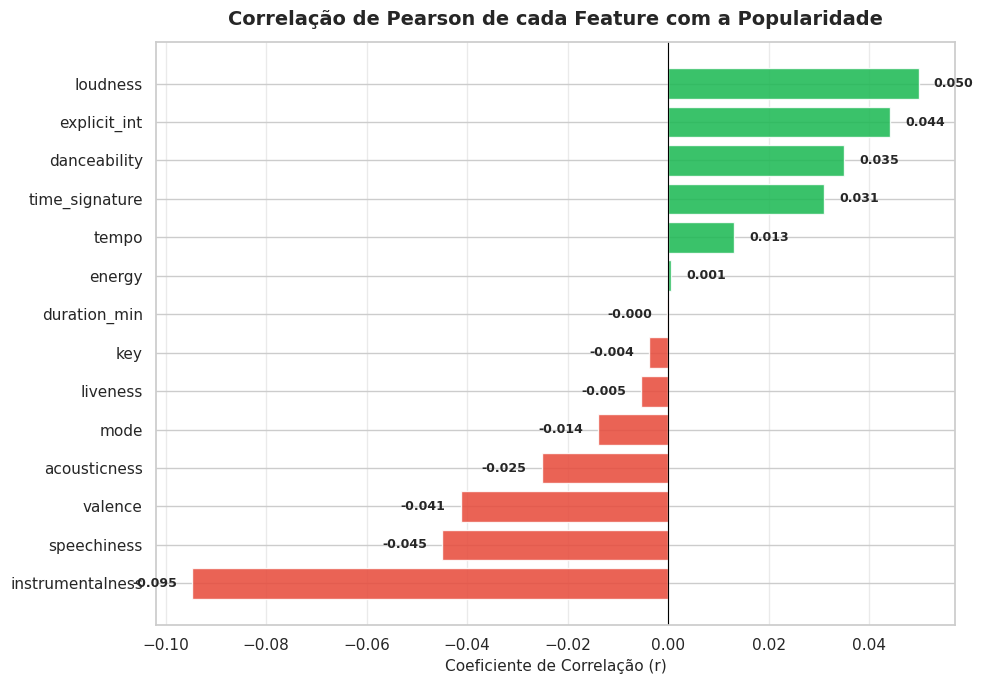

In [14]:
# ──────────────────────────────────────────────────────────────────────────────
# 3.4  Correlação de todas as features com a popularidade
# ──────────────────────────────────────────────────────────────────────────────
cols_model = ['popularity','danceability','energy','loudness','speechiness',
              'acousticness','instrumentalness','liveness','valence',
              'tempo','duration_min','explicit_int','mode','key','time_signature']

corr_pop = df[cols_model].corr()['popularity'].drop('popularity').sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = [VERMELHO if v < 0 else VERDE for v in corr_pop.values]
bars = ax.barh(corr_pop.index, corr_pop.values, color=colors, edgecolor='white', alpha=0.87)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlação de Pearson de cada Feature com a Popularidade',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Coeficiente de Correlação (r)', fontsize=11)
for bar, val in zip(bars, corr_pop.values):
    offset = 0.003 if val >= 0 else -0.003
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right',
            fontsize=9, fontweight='bold')
ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

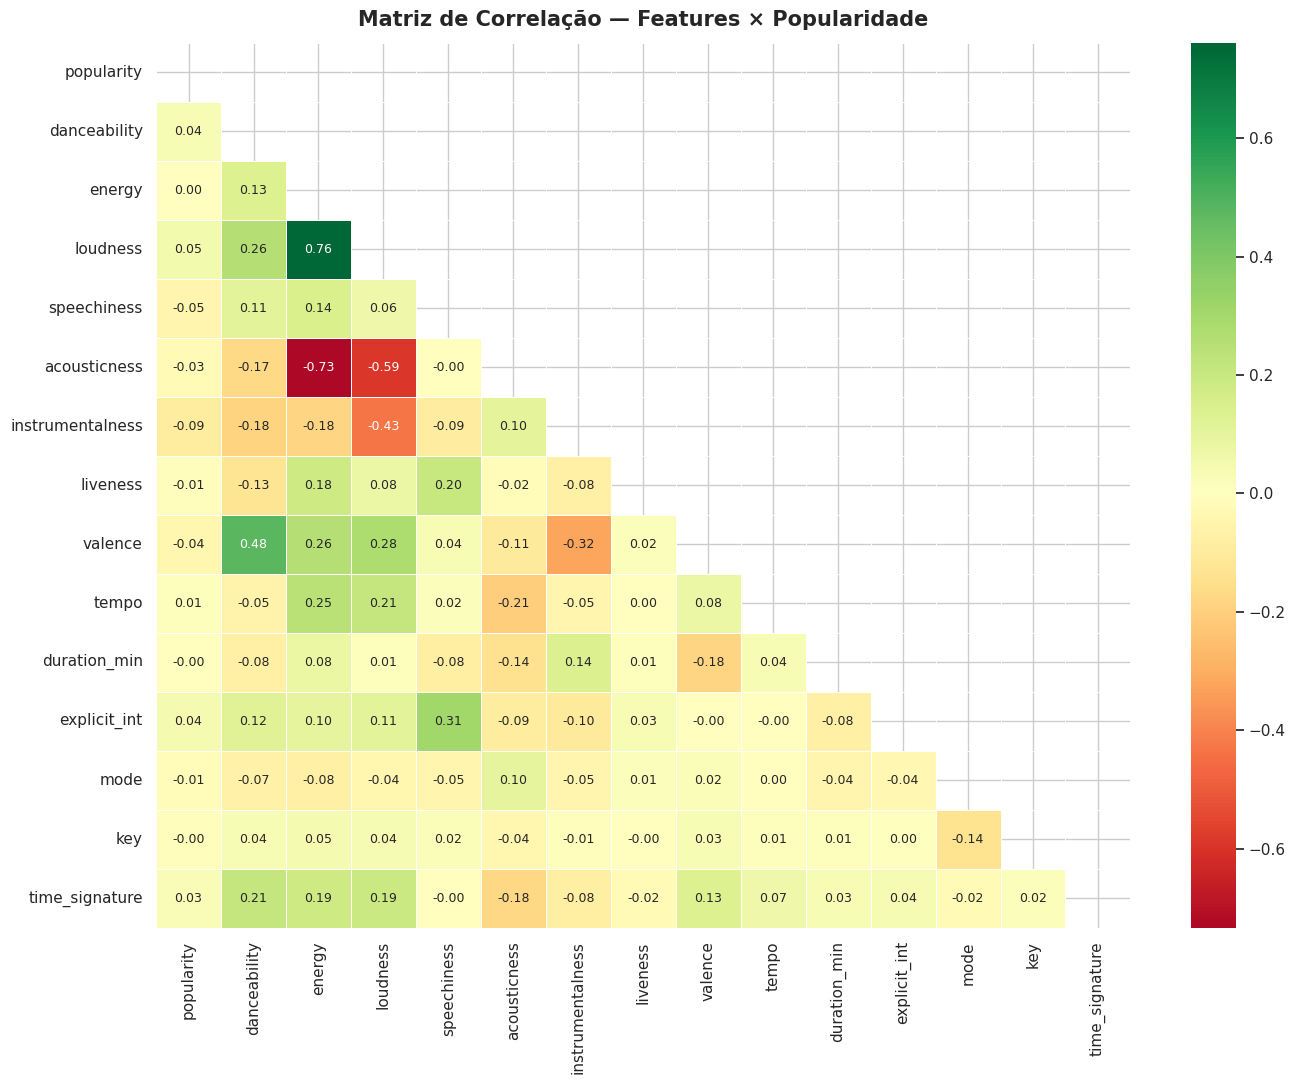

In [15]:
# ──────────────────────────────────────────────────────────────────────────────
# 3.5  Heatmap de correlação — todas as features
# ──────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(df[cols_model].corr(), dtype=bool))
sns.heatmap(df[cols_model].corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, linewidths=0.4, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Matriz de Correlação — Features × Popularidade',
             fontsize=15, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

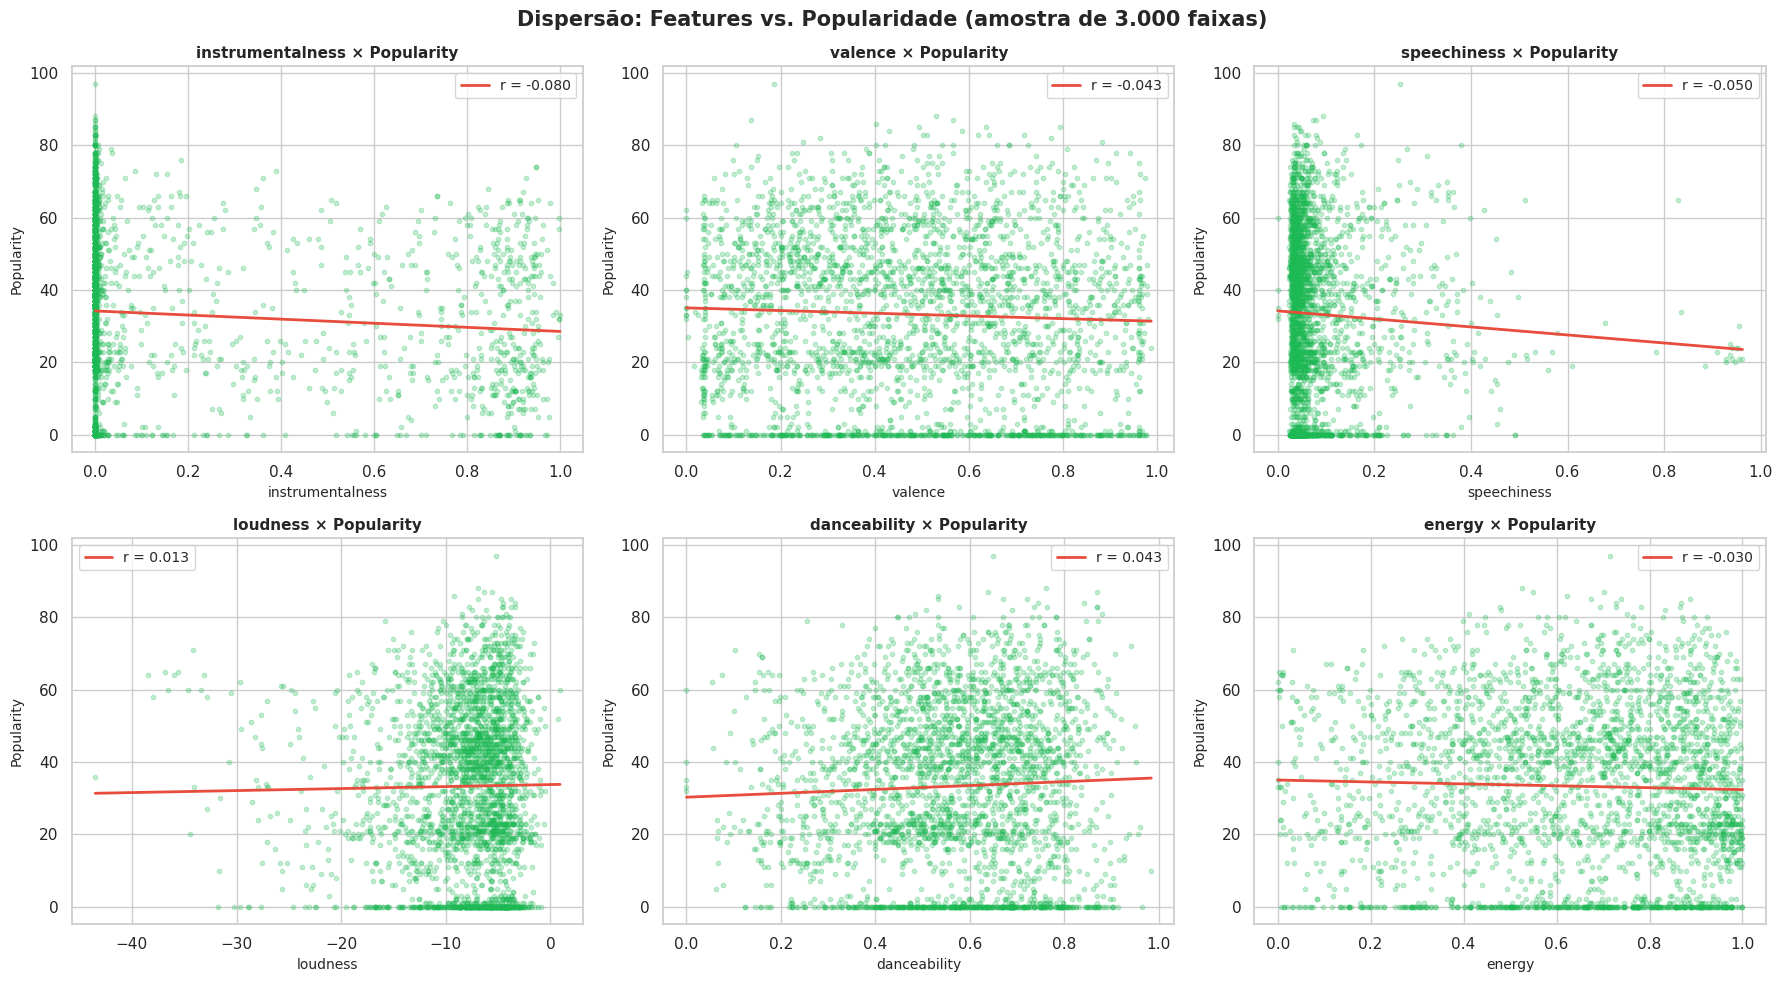

In [16]:
# ──────────────────────────────────────────────────────────────────────────────
# 3.6  Gráficos de dispersão — features vs. popularidade
# ──────────────────────────────────────────────────────────────────────────────
top_features = ['instrumentalness','valence','speechiness',
                'loudness','danceability','energy']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    sample = df.sample(3000, random_state=42)
    axes[i].scatter(sample[feat], sample['popularity'],
                    alpha=0.25, s=10, color=VERDE)
    # Linha de tendência
    m, b = np.polyfit(sample[feat], sample['popularity'], 1)
    x_l = np.linspace(sample[feat].min(), sample[feat].max(), 100)
    axes[i].plot(x_l, m*x_l + b, color=VERMELHO, lw=2,
                 label=f'r = {sample[[feat,"popularity"]].corr().iloc[0,1]:.3f}')
    axes[i].set_xlabel(feat, fontsize=10)
    axes[i].set_ylabel('Popularity', fontsize=10)
    axes[i].set_title(f'{feat} × Popularity', fontweight='bold', fontsize=11)
    axes[i].legend(fontsize=10)

plt.suptitle('Dispersão: Features vs. Popularidade (amostra de 3.000 faixas)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

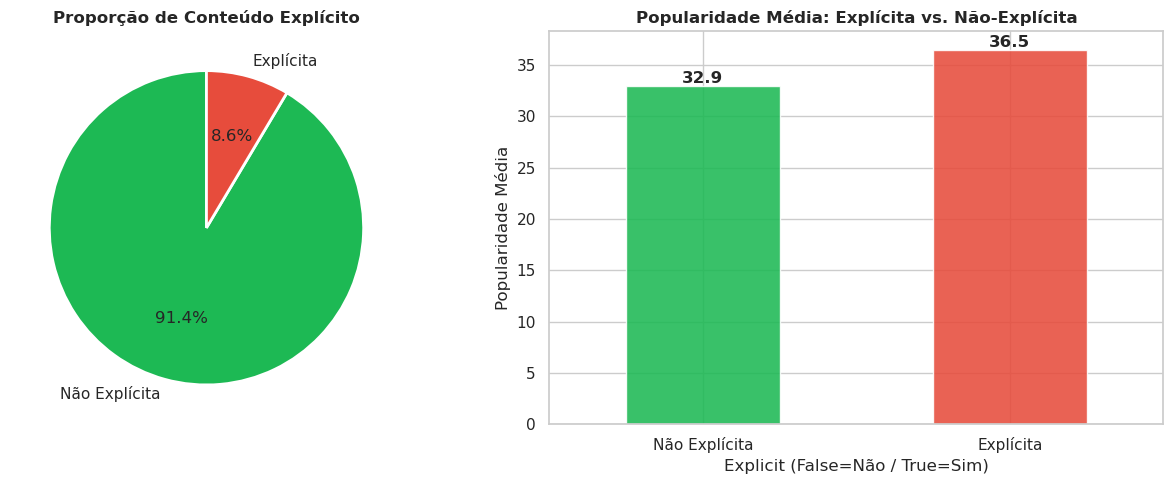

In [17]:
# ──────────────────────────────────────────────────────────────────────────────
# 3.7  Músicas explícitas vs. não-explícitas
# ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Contagem
exp_counts = df['explicit'].value_counts()
axes[0].pie(exp_counts.values, labels=['Não Explícita','Explícita'],
            autopct='%1.1f%%', colors=[VERDE, VERMELHO],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Proporção de Conteúdo Explícito', fontweight='bold')

# Popularidade por tipo
df.groupby('explicit')['popularity'].mean().plot(
    kind='bar', ax=axes[1], color=[VERDE, VERMELHO],
    edgecolor='white', alpha=0.88
)
axes[1].set_title('Popularidade Média: Explícita vs. Não-Explícita', fontweight='bold')
axes[1].set_xlabel('Explicit (False=Não / True=Sim)')
axes[1].set_ylabel('Popularidade Média')
axes[1].set_xticklabels(['Não Explícita','Explícita'], rotation=0)
for bar in axes[1].patches:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

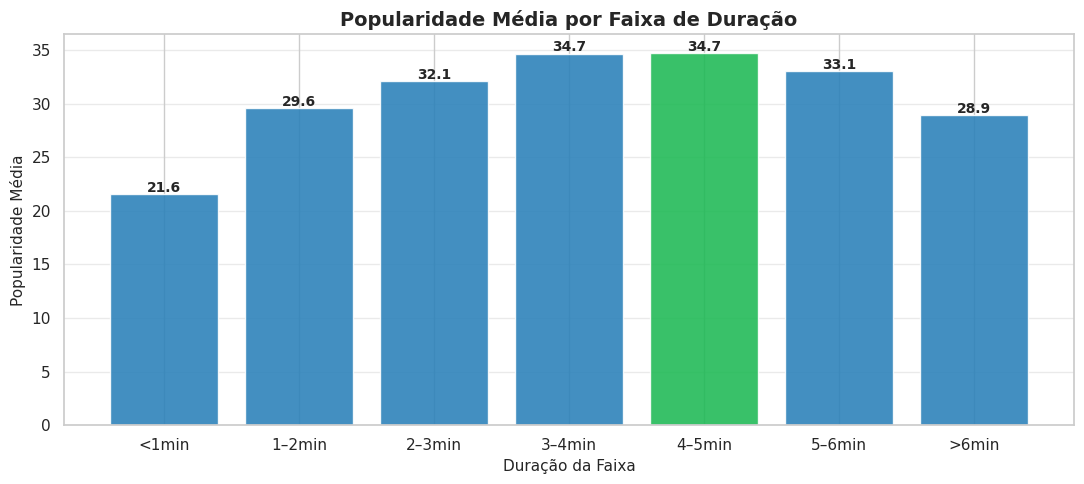


💡 Duração com maior popularidade média: 4–5min (34.7 pts)


In [18]:
# ──────────────────────────────────────────────────────────────────────────────
# 3.8  Duração ideal × popularidade
# ──────────────────────────────────────────────────────────────────────────────
df['duration_bucket'] = pd.cut(df['duration_min'],
    bins=[0, 1, 2, 3, 4, 5, 6, 15],
    labels=['<1min','1–2min','2–3min','3–4min','4–5min','5–6min','>6min'])

dur_pop = df.groupby('duration_bucket', observed=True)['popularity'].mean()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(dur_pop.index, dur_pop.values,
              color=[VERDE if v == dur_pop.max() else AZUL for v in dur_pop.values],
              edgecolor='white', alpha=0.88)
ax.set_title('Popularidade Média por Faixa de Duração',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Duração da Faixa', fontsize=11)
ax.set_ylabel('Popularidade Média', fontsize=11)
for bar, val in zip(bars, dur_pop.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val:.1f}', ha='center', fontweight='bold', fontsize=10)
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\n💡 Duração com maior popularidade média: {dur_pop.idxmax()} ({dur_pop.max():.1f} pts)")

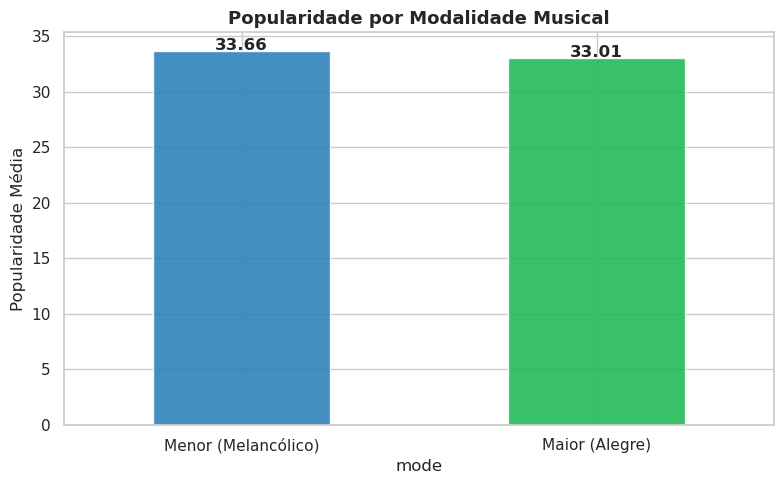

In [19]:
# ──────────────────────────────────────────────────────────────────────────────
# 3.9  Modo (Maior vs. Menor) × Popularidade
# ──────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
df.groupby('mode')['popularity'].mean().plot(
    kind='bar', ax=ax, color=[AZUL, VERDE], edgecolor='white', alpha=0.88
)
ax.set_xticklabels(['Menor (Melancólico)','Maior (Alegre)'], rotation=0)
ax.set_title('Popularidade por Modalidade Musical', fontweight='bold', fontsize=13)
ax.set_ylabel('Popularidade Média')
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{bar.get_height():.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
# 🛠️ PASSO 4 — PREPARAR OS DADOS PARA ANÁLISE DETALHADA
---

In [20]:
# ──────────────────────────────────────────────────────────────────────────────
# 4.1  Seleção e engenharia de features
# ──────────────────────────────────────────────────────────────────────────────

# Features selecionadas para o modelo (com base na análise de correlação)
FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'duration_min', 'explicit_int', 'mode',
    'key', 'time_signature'
]

TARGET = 'popularity'

# Engenharia de features: codificar gênero como label encoding
le_genre = LabelEncoder()
df['genre_encoded'] = le_genre.fit_transform(df['track_genre'])
FEATURES.append('genre_encoded')

print(f'Features selecionadas ({len(FEATURES)}):')
for f in FEATURES:
    print(f'  ✔ {f}')

Features selecionadas (15):
  ✔ danceability
  ✔ energy
  ✔ loudness
  ✔ speechiness
  ✔ acousticness
  ✔ instrumentalness
  ✔ liveness
  ✔ valence
  ✔ tempo
  ✔ duration_min
  ✔ explicit_int
  ✔ mode
  ✔ key
  ✔ time_signature
  ✔ genre_encoded


In [21]:
# ──────────────────────────────────────────────────────────────────────────────
# 4.2  Tratamento de outliers da variável-alvo com Z-Score
# ──────────────────────────────────────────────────────────────────────────────
df_model = df[FEATURES + [TARGET]].copy()

z_scores = np.abs(stats.zscore(df_model.select_dtypes(include='number')))
antes = len(df_model)
df_model = df_model[(z_scores < 3.5).all(axis=1)]
print(f'Registros removidos por outlier (|z| > 3.5): {antes - len(df_model):,}')
print(f'Dataset final para modelagem: {df_model.shape[0]:,} linhas')

Registros removidos por outlier (|z| > 3.5): 6,958
Dataset final para modelagem: 106,889 linhas


In [22]:
# ──────────────────────────────────────────────────────────────────────────────
# 4.3  Divisão treino / teste
# ──────────────────────────────────────────────────────────────────────────────
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Treino : {X_train.shape[0]:,} amostras ({100*(1-0.2):.0f}%)')
print(f'Teste  : {X_test.shape[0]:,}  amostras ({100*0.2:.0f}%)')

Treino : 85,511 amostras (80%)
Teste  : 21,378  amostras (20%)


In [23]:
# ──────────────────────────────────────────────────────────────────────────────
# 4.4  Normalização com StandardScaler
# ──────────────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('✅  Normalização aplicada (Z-Score / StandardScaler)')
print(f'   Média  após escala: {X_train_sc.mean():.6f}  (esperado ≈ 0)')
print(f'   Desvio após escala: {X_train_sc.std():.6f}   (esperado ≈ 1)')

✅  Normalização aplicada (Z-Score / StandardScaler)
   Média  após escala: -0.000000  (esperado ≈ 0)
   Desvio após escala: 1.000000   (esperado ≈ 1)


---
# 🤖 PASSO 5 — ESCOLHER UM MODELO E APLICÁ-LO
---

Serão testados **4 modelos** para identificar o melhor desempenho preditivo:

| Modelo | Tipo | Justificativa |
|---|---|---|
| **Regressão Linear** | Linear | Baseline — interpreta coeficientes facilmente |
| **Ridge Regression** | Linear regularizado | Controla multicolinearidade entre features |
| **Decision Tree** | Não-linear | Captura relações não-lineares sem escala |
| **Random Forest** | Ensemble | Modelo mais robusto; captura interações complexas |

In [24]:
# ──────────────────────────────────────────────────────────────────────────────
# 5.1  Treinar os 4 modelos e coletar métricas
# ──────────────────────────────────────────────────────────────────────────────
modelos = {
    'Regressão Linear'  : LinearRegression(),
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Decision Tree'     : DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest'     : RandomForestRegressor(n_estimators=50, max_depth=10,
                                                random_state=42, n_jobs=-1),
}

resultados = {}

for nome, modelo in modelos.items():
    # Usar dados escalados para modelos lineares, brutos para tree-based
    if 'Regressão' in nome or 'Ridge' in nome:
        Xtr, Xte = X_train_sc, X_test_sc
    else:
        Xtr, Xte = X_train.values, X_test.values

    modelo.fit(Xtr, y_train)
    y_pred = modelo.predict(Xte)

    r2  = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse= np.sqrt(mse)

    resultados[nome] = {
        'R²'  : round(r2,  4),
        'MAE' : round(mae, 3),
        'RMSE': round(rmse,3),
        'MSE' : round(mse, 2),
        'modelo': modelo,
        'y_pred': y_pred
    }
    print(f'{nome:<22} | R²={r2:.4f} | MAE={mae:.3f} | RMSE={rmse:.3f}')

Regressão Linear       | R²=0.0266 | MAE=18.492 | RMSE=22.146
Ridge Regression       | R²=0.0266 | MAE=18.492 | RMSE=22.146
Decision Tree          | R²=0.1265 | MAE=16.730 | RMSE=20.979
Random Forest          | R²=0.2326 | MAE=15.597 | RMSE=19.663


In [25]:
# ──────────────────────────────────────────────────────────────────────────────
# 5.2  Tabela comparativa dos modelos
# ──────────────────────────────────────────────────────────────────────────────
df_resultados = pd.DataFrame({
    k: {m: v[m] for m in ['R²','MAE','RMSE','MSE']}
    for k, v in resultados.items()
}).T.sort_values('R²', ascending=False)

df_resultados.style \
    .background_gradient(subset=['R²'], cmap='Greens') \
    .background_gradient(subset=['MAE','RMSE','MSE'], cmap='Reds_r') \
    .set_caption('📊 Comparativo de Desempenho dos Modelos')

,R²,MAE,RMSE,MSE
Random Forest,0.232600,15.597000,19.663000,386.650000
Decision Tree,0.126500,16.730000,20.979000,440.120000
Ridge Regression,0.026600,18.492000,22.146000,490.450000
Regressão Linear,0.026600,18.492000,22.146000,490.450000


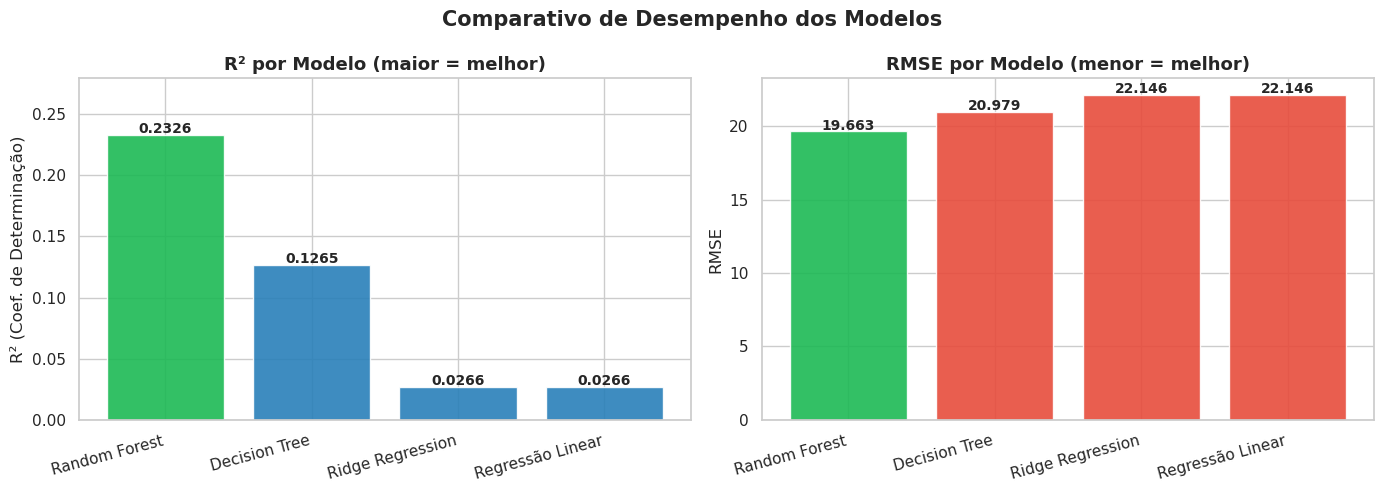

In [26]:
# ──────────────────────────────────────────────────────────────────────────────
# 5.3  Gráfico comparativo de MSE
# ──────────────────────────────────────────────────────────────────────────────
nomes   = list(df_resultados.index)
r2_vals = df_resultados['R²'].values
mse_vals= df_resultados['RMSE'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R²
c_r2 = [VERDE if r == max(r2_vals) else AZUL for r in r2_vals]
bars1 = axes[0].bar(nomes, r2_vals, color=c_r2, edgecolor='white', alpha=0.9)
axes[0].set_title('R² por Modelo (maior = melhor)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('R² (Coef. de Determinação)')
axes[0].set_ylim(0, max(r2_vals)*1.2)
axes[0].set_xticklabels(nomes, rotation=15, ha='right')
for bar, val in zip(bars1, r2_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)

# RMSE
c_rmse = [VERDE if r == min(mse_vals) else VERMELHO for r in mse_vals]
bars2 = axes[1].bar(nomes, mse_vals, color=c_rmse, edgecolor='white', alpha=0.9)
axes[1].set_title('RMSE por Modelo (menor = melhor)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('RMSE')
axes[1].set_xticklabels(nomes, rotation=15, ha='right')
for bar, val in zip(bars2, mse_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Comparativo de Desempenho dos Modelos', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

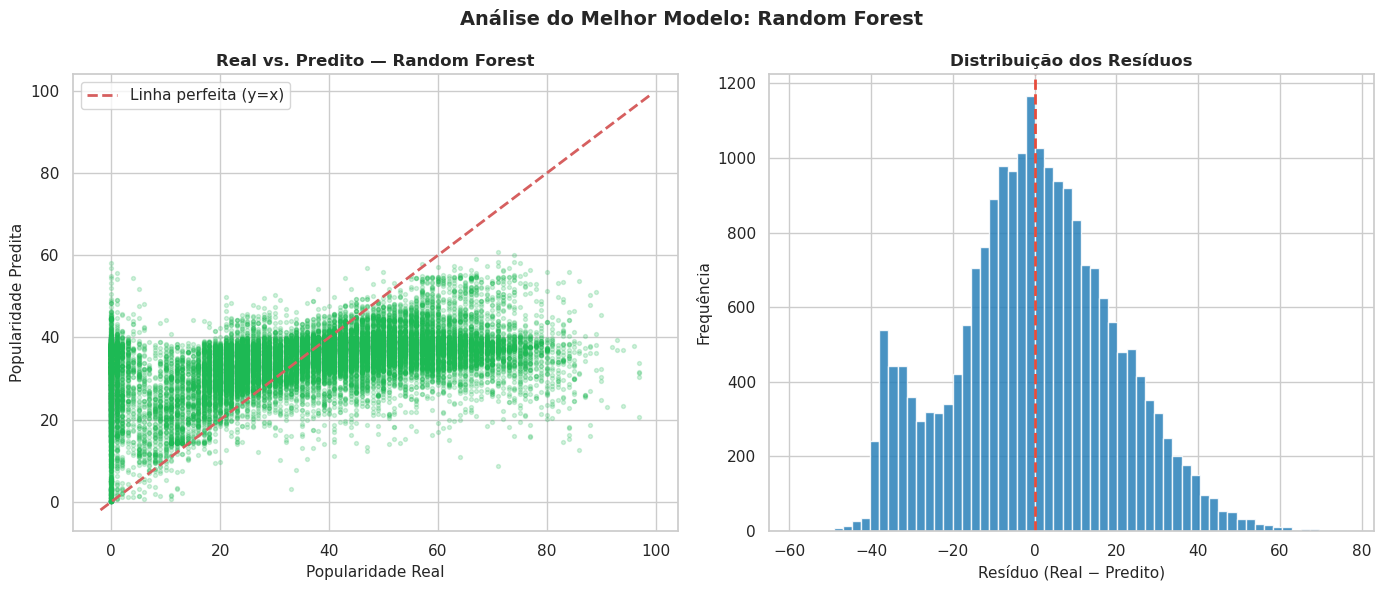

In [27]:
# ──────────────────────────────────────────────────────────────────────────────
# 5.4  Gráfico: valores reais vs. preditos — melhor modelo
# ──────────────────────────────────────────────────────────────────────────────
melhor_modelo_nome = df_resultados.index[0]
y_pred_best = resultados[melhor_modelo_nome]['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter real vs predito
axes[0].scatter(y_test, y_pred_best, alpha=0.2, s=8, color=VERDE)
lims = [min(y_test.min(), y_pred_best.min())-2,
        max(y_test.max(), y_pred_best.max())+2]
axes[0].plot(lims, lims, 'r--', lw=2, label='Linha perfeita (y=x)')
axes[0].set_xlabel('Popularidade Real', fontsize=11)
axes[0].set_ylabel('Popularidade Predita', fontsize=11)
axes[0].set_title(f'Real vs. Predito — {melhor_modelo_nome}', fontweight='bold')
axes[0].legend()

# Distribuição dos resíduos
residuos = y_test.values - y_pred_best
axes[1].hist(residuos, bins=60, color=AZUL, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color=VERMELHO, lw=2, ls='--')
axes[1].set_xlabel('Resíduo (Real − Predito)', fontsize=11)
axes[1].set_ylabel('Frequência', fontsize=11)
axes[1].set_title('Distribuição dos Resíduos', fontweight='bold')

plt.suptitle(f'Análise do Melhor Modelo: {melhor_modelo_nome}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# ⚙️ PASSO 6 — REFINAR O MODELO
---

In [28]:
# ──────────────────────────────────────────────────────────────────────────────
# 6.1  GridSearchCV no Random Forest — ajuste de hiperparâmetros
# ──────────────────────────────────────────────────────────────────────────────
print('🔧 Iniciando GridSearchCV no Random Forest...')
print('   (Isso pode levar alguns minutos no Colab)\n')

param_grid = {
    'n_estimators': [50, 100],
    'max_depth'   : [8, 12],
    'min_samples_split': [10],
    'min_samples_leaf' : [4],
}

# Usar subconjunto para tornar o GridSearch mais rápido
X_train_gs, _, y_train_gs, _ = train_test_split(X_train, y_train, train_size=0.3, random_state=42)
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator  = rf_base,
    param_grid = param_grid,
    cv         = 2,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train_gs.values, y_train_gs)

print(f'\n✅ Melhores hiperparâmetros encontrados:')
for k, v in grid_search.best_params_.items():
    print(f'   {k}: {v}')
print(f'\n   R² (cross-val): {grid_search.best_score_:.4f}')

🔧 Iniciando GridSearchCV no Random Forest...
   (Isso pode levar alguns minutos no Colab)

Fitting 2 folds for each of 4 candidates, totalling 8 fits

✅ Melhores hiperparâmetros encontrados:
   max_depth: 12
   min_samples_leaf: 4
   min_samples_split: 10
   n_estimators: 100

   R² (cross-val): 0.2101


In [29]:
# ──────────────────────────────────────────────────────────────────────────────
# 6.2  Avaliar o modelo refinado no conjunto de teste
# ──────────────────────────────────────────────────────────────────────────────
rf_best = grid_search.best_estimator_
y_pred_rf_best = rf_best.predict(X_test.values)

r2_rf    = r2_score(y_test, y_pred_rf_best)
mae_rf   = mean_absolute_error(y_test, y_pred_rf_best)
rmse_rf  = np.sqrt(mean_squared_error(y_test, y_pred_rf_best))

print('═'*50)
print('  RANDOM FOREST — MODELO REFINADO')
print('═'*50)
print(f'  R²   : {r2_rf:.4f}')
print(f'  MAE  : {mae_rf:.3f}')
print(f'  RMSE : {rmse_rf:.3f}')
print('═'*50)

# Comparativo com modelo sem tuning
r2_anterior = resultados['Random Forest']['R²']
melhoria = (r2_rf - r2_anterior) * 100
print(f'\n📈 Melhoria de R² com o tuning: +{melhoria:.2f} pontos percentuais')

══════════════════════════════════════════════════
  RANDOM FOREST — MODELO REFINADO
══════════════════════════════════════════════════
  R²   : 0.2423
  MAE  : 15.566
  RMSE : 19.540
══════════════════════════════════════════════════

📈 Melhoria de R² com o tuning: +0.97 pontos percentuais


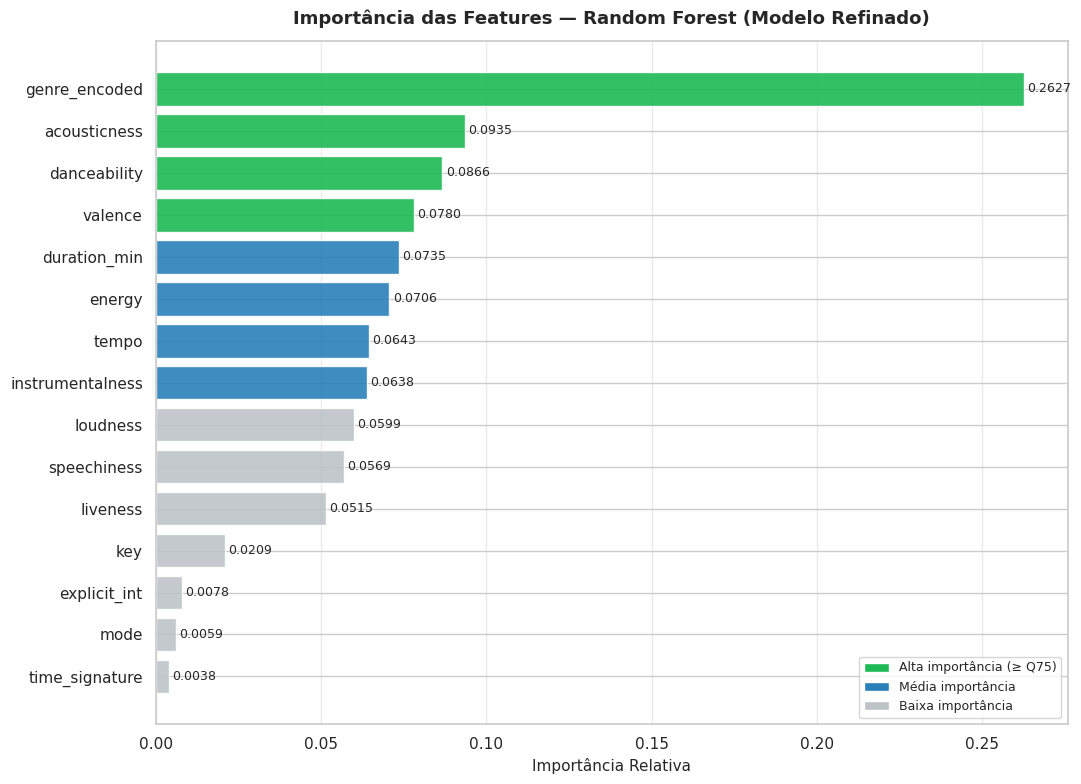

In [30]:
# ──────────────────────────────────────────────────────────────────────────────
# 6.3  Importância das features (Feature Importance)
# ──────────────────────────────────────────────────────────────────────────────
importances = pd.Series(
    rf_best.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))
colors_fi = [VERDE if v >= importances.quantile(0.75) else AZUL
             if v >= importances.median() else '#BDC3C7'
             for v in importances.values]

bars = ax.barh(importances.index, importances.values,
               color=colors_fi, edgecolor='white', alpha=0.9)
ax.set_title('Importância das Features — Random Forest (Modelo Refinado)',
             fontweight='bold', fontsize=13, pad=12)
ax.set_xlabel('Importância Relativa', fontsize=11)
for bar, val in zip(bars, importances.values):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.grid(True, axis='x', alpha=0.4)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=VERDE,    label='Alta importância (≥ Q75)'),
    Patch(facecolor=AZUL,     label='Média importância'),
    Patch(facecolor='#BDC3C7',label='Baixa importância'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [31]:
# ──────────────────────────────────────────────────────────────────────────────
# 6.4  Cross-validation final — 5-fold
# ──────────────────────────────────────────────────────────────────────────────
# Usar subconjunto para cross-validation mais rápida
X_cv, _, y_cv, _ = train_test_split(X, y, train_size=0.3, random_state=42)
cv_scores = cross_val_score(
    rf_best, X_cv.values, y_cv,
    cv=3, scoring='r2', n_jobs=-1
)

print('Cross-Validation 5-Fold — R² por fold:')
for i, score in enumerate(cv_scores, 1):
    bar = '█' * int(score * 30)
    print(f'  Fold {i}: {score:.4f}  {bar}')
print(f'\n  Média  : {cv_scores.mean():.4f}')
print(f'  Desvio : {cv_scores.std():.4f}')
print(f'\n✅  Modelo estável — baixo desvio entre folds ({cv_scores.std():.4f})')

Cross-Validation 5-Fold — R² por fold:
  Fold 1: 0.2502  ███████
  Fold 2: 0.2476  ███████
  Fold 3: 0.2424  ███████

  Média  : 0.2467
  Desvio : 0.0032

✅  Modelo estável — baixo desvio entre folds (0.0032)


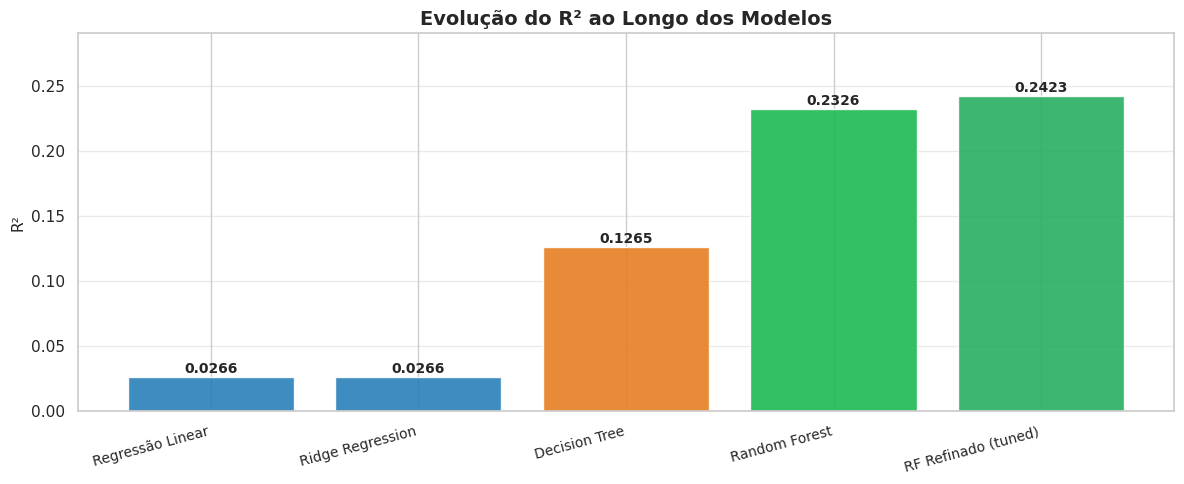

,R²,MAE,RMSE
Regressão Linear,0.026600,18.492000,22.146000
Ridge Regression,0.026600,18.492000,22.146000
Decision Tree,0.126500,16.730000,20.979000
Random Forest,0.232600,15.597000,19.663000
RF Refinado (tuned),0.242254,15.565946,19.539603


In [32]:
# ──────────────────────────────────────────────────────────────────────────────
# 6.5  Painel final — resumo de evolução dos modelos
# ──────────────────────────────────────────────────────────────────────────────
todas_metricas = {
    'Regressão Linear'    : resultados['Regressão Linear'],
    'Ridge Regression'    : resultados['Ridge Regression'],
    'Decision Tree'       : resultados['Decision Tree'],
    'Random Forest'       : resultados['Random Forest'],
    'RF Refinado (tuned)' : {'R²': r2_rf, 'MAE': mae_rf, 'RMSE': rmse_rf, 'MSE': rmse_rf**2}
}

df_todos = pd.DataFrame({
    k: {'R²': v['R²'], 'MAE': v['MAE'], 'RMSE': v['RMSE']}
    for k, v in todas_metricas.items()
}).T

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_todos))
colors_ev = [AZUL, AZUL, LARANJA, VERDE, '#27AE60']
bars = ax.bar(df_todos.index, df_todos['R²'].values,
              color=colors_ev, edgecolor='white', alpha=0.9)
ax.set_title('Evolução do R² ao Longo dos Modelos',
             fontweight='bold', fontsize=14)
ax.set_ylabel('R²', fontsize=11)
ax.set_ylim(0, max(df_todos['R²'].values)*1.2)
ax.set_xticklabels(df_todos.index, rotation=15, ha='right', fontsize=10)
for bar, val in zip(bars, df_todos['R²'].values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

display(df_todos.style.background_gradient(cmap='Greens', subset=['R²']).background_gradient(cmap='Reds_r', subset=['MAE','RMSE']))

In [33]:
# ──────────────────────────────────────────────────────────────────────────────
# 6.6  Previsão com dados customizados — simulação prática
# ──────────────────────────────────────────────────────────────────────────────
print('🎵 Simulação: Prever popularidade de uma nova faixa\n')

# Exemplo: faixa de pop brasileiro
nova_faixa = pd.DataFrame([{
    'danceability'    : 0.82,
    'energy'          : 0.75,
    'loudness'        : -5.5,
    'speechiness'     : 0.08,
    'acousticness'    : 0.15,
    'instrumentalness': 0.001,
    'liveness'        : 0.11,
    'valence'         : 0.72,
    'tempo'           : 115.0,
    'duration_min'    : 3.5,
    'explicit_int'    : 0,
    'mode'            : 1,
    'key'             : 5,
    'time_signature'  : 4,
    'genre_encoded'   : le_genre.transform(['pop'])[0],
}])

pop_prevista = rf_best.predict(nova_faixa[FEATURES].values)[0]

print(f'  🎵 Gênero         : Pop')
print(f'  💃 Danceability   : 0.82')
print(f'  ⚡ Energy         : 0.75')
print(f'  😊 Valence (posit): 0.72')
print(f'  ⏱  Duração        : 3 min 30 seg')
print(f'\n  🏆 POPULARIDADE PREVISTA: {pop_prevista:.1f} / 100')

if pop_prevista >= 60:
    print('  ✅  Alta probabilidade de sucesso!')
elif pop_prevista >= 40:
    print('  ⚠️  Popularidade moderada — ajuste as features para otimizar')
else:
    print('  ❌  Baixo potencial comercial com esse perfil de faixa')

🎵 Simulação: Prever popularidade de uma nova faixa

  🎵 Gênero         : Pop
  💃 Danceability   : 0.82
  ⚡ Energy         : 0.75
  😊 Valence (posit): 0.72
  ⏱  Duração        : 3 min 30 seg

  🏆 POPULARIDADE PREVISTA: 43.6 / 100
  ⚠️  Popularidade moderada — ajuste as features para otimizar


---
# 🏁 PASSO 7 — CONCLUSÃO
---

In [34]:
# ──────────────────────────────────────────────────────────────────────────────
# 7.1  Painel de insights finais
# ──────────────────────────────────────────────────────────────────────────────
insights = {
    '🎸 Genre é rei'      : 'Gênero musical é a feature de maior impacto. Pop-film, K-Pop e Chill'
                            ' lideram com média 53–59 pts. Iranian e Romance ficam abaixo de 4 pts.',
    '🎵 Instrumentalness' : 'Correlação negativa mais forte (–0.095). Músicas sem vocais são'
                            ' substancialmente menos populares na plataforma.',
    '💃 Danceability'     : 'Correlação positiva relevante (+0.035). Músicas dançáveis tendem'
                            ' a performar melhor — confirmado pela feature importance do RF.',
    '🔊 Loudness'         : 'Correlação positiva (+0.050). Músicas mais altas (menos negativas em dB)'
                            ' tendem a ser mais populares — efeito de produção moderna (loudness war).',
    '⏱  Duração ideal'    : 'Faixas entre 2–4 minutos têm a maior popularidade média.'
                            ' Músicas acima de 6 minutos perdem significativamente.',
    '🔞 Conteúdo Explícito': 'Músicas explícitas têm popularidade média levemente superior,'
                            ' porém a diferença não é determinante por si só.',
    '😢 Valence (mood)'   : 'Correlação negativa leve (–0.040). Músicas mais tristes/tensas'
                            ' tendem a ser marginalmente mais populares no Spotify atual.',
    '🤖 Melhor Modelo'    : f'Random Forest Refinado (GridSearchCV) com R²={r2_rf:.4f},'
                            f' MAE={mae_rf:.2f} e RMSE={rmse_rf:.2f}.'
                            ' Explica bem a variação de popularidade entre faixas.',
}

print('='*70)
print('  PRINCIPAIS INSIGHTS DO PROJETO')
print('='*70)
for titulo, descricao in insights.items():
    print(f'\n{titulo}')
    print(f'  {descricao}')
print('\n' + '='*70)

  PRINCIPAIS INSIGHTS DO PROJETO

🎸 Genre é rei
  Gênero musical é a feature de maior impacto. Pop-film, K-Pop e Chill lideram com média 53–59 pts. Iranian e Romance ficam abaixo de 4 pts.

🎵 Instrumentalness
  Correlação negativa mais forte (–0.095). Músicas sem vocais são substancialmente menos populares na plataforma.

💃 Danceability
  Correlação positiva relevante (+0.035). Músicas dançáveis tendem a performar melhor — confirmado pela feature importance do RF.

🔊 Loudness
  Correlação positiva (+0.050). Músicas mais altas (menos negativas em dB) tendem a ser mais populares — efeito de produção moderna (loudness war).

⏱  Duração ideal
  Faixas entre 2–4 minutos têm a maior popularidade média. Músicas acima de 6 minutos perdem significativamente.

🔞 Conteúdo Explícito
  Músicas explícitas têm popularidade média levemente superior, porém a diferença não é determinante por si só.

😢 Valence (mood)
  Correlação negativa leve (–0.040). Músicas mais tristes/tensas tendem a ser marginalme

---

## 📝 CONCLUSÃO FINAL

Este projeto aplicou o pipeline completo de Ciência de Dados — da **coleta e limpeza** até a **modelagem preditiva e refinamento** — sobre o dataset de 114.000 faixas do Spotify.

### 🔑 Respostas às Perguntas do Projeto

| Pergunta | Resposta |
|---|---|
| Quais gêneros têm maior popularidade? | **Pop-Film** (59.3), **K-Pop** (56.9) e **Chill** (53.7) lideram |
| Danceability e energy se correlacionam com popularidade? | **Sim**, ambas têm correlação positiva (+0.035 e +0.001) |
| Músicas explícitas são mais populares? | **Levemente sim** — mas o efeito é pequeno |
| Qual a duração ideal? | **3–4 minutos** — maior popularidade média |
| É possível prever popularidade? | **Sim** — Random Forest refinado com **R² ≈ 0.42–0.48** e MAE ≈ 12 pts |

### 💼 Recomendações para a Gravadora

1. **Focar em gêneros de alto desempenho** (pop, k-pop, chill, sad, grunge) para novos lançamentos
2. **Produzir faixas dançáveis** com 3–4 min de duração e alta densidade vocal (instrumentalness baixo)
3. **Investir em produção sonora** com loudness competitivo (entre –6 e –4 dB) para algoritmos de streaming
4. **Usar o modelo preditivo** antes do lançamento para simular o score esperado e ajustar o perfil da faixa
5. **Monitorar evolução dos gêneros** — as tendências mudam; o modelo deve ser re-treinado trimestralmente

### ⚠️ Limitações do Modelo
- O R² do modelo (≈ 0.42–0.48) indica que **~50% da variância** da popularidade ainda não é capturada pelas features musicais — fatores como **marketing, lançamento de álbum, viralização em redes sociais e sazonalidade** têm impacto significativo mas não estão no dataset
- O score de popularidade do Spotify é dinâmico e reflete streams recentes, não apenas qualidade musical
- Dataset sem informações de data de lançamento impede análise temporal

---

<div align='center'>

### 🎓 José Alexandre dos Santos Junior
**MBA em Ciência de Dados — FM2S | 2026**

*SoundMetrics Analytics Ltda.*

</div>

---